# Módulo 1: Exploración de Datos — Riesgo Operacional (CBK)

**Grupo 3** — Analítica Digital UCEMA 2026  
**Integrantes**: Ivan Charczuk, Robertino Barbuto, Sofia Martinez Luque

**Objetivo**: Explorar el dataset de órdenes enriquecido para entender la magnitud del riesgo por Chargebacks (CBK), identificar sus predictores y cuantificar el impacto en el margen de Olist.

## 1. Imports y Carga de Datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np
import os

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

os.makedirs('img', exist_ok=True)
os.makedirs('exports_tableau', exist_ok=True)

In [2]:
# Ajustar ruta según donde tengas los archivos
df = pd.read_csv('olist_order_items_enriched.csv')

print(f'Registros: {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')
df.head()

Registros: 112,647
Columnas: 27


,order_id,order_item_id,product_id,seller_id,order_status,shipping_limit_date,price,payment_value,tpv_base,financing_revenue,...,discount,freight_value,has_shipping,cbk,status_cbk,profit,product_category_name,product_weight_g,payment_installments,discount_pct
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,delivered,2017-09-19 09:45:35,58.90,72.19,72.19,1.94913,...,4.7120,13.29,1,0,NaN,27.37036,cool_stuff,650.0,2.0,0.08
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,delivered,2017-05-03 11:05:13,239.90,259.83,259.83,11.43252,...,19.1920,0.00,0,0,NaN,135.00221,pet_shop,30000.0,3.0,0.08
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,delivered,2018-01-18 14:48:30,199.00,216.87,216.87,0.00000,...,15.9200,17.87,1,0,NaN,93.06074,moveis_decoracao,3050.0,5.0,0.08
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,delivered,2018-08-15 10:10:18,12.99,25.78,25.78,0.69606,...,1.0392,12.79,1,0,NaN,5.00519,perfumaria,200.0,2.0,0.08
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,delivered,2017-02-13 13:57:51,199.90,218.04,218.04,9.59376,...,15.9920,18.14,1,0,NaN,96.10526,ferramentas_jardim,3750.0,3.0,0.08


## 2. Estadísticas Descriptivas

In [3]:
cols_analisis = ['price', 'profit', 'cbk', 'payment_installments',
                 'freight_value', 'discount', 'overhead_cost']
df[cols_analisis].describe().round(2)

,price,profit,cbk,payment_installments,freight_value,discount,overhead_cost
count,112647.00,112647.00,112647.00,112647.00,112647.00,112647.00,112647.0
mean,120.66,96.54,0.02,3.02,15.31,9.85,1.5
std,183.64,202.98,0.16,2.80,10.38,14.89,0.0
min,0.85,-110.13,0.00,0.00,0.00,0.07,1.5
25%,39.90,22.24,0.00,1.00,9.55,3.26,1.5
50%,74.99,47.93,0.00,2.00,15.10,6.23,1.5
75%,134.90,101.16,0.00,4.00,18.57,11.12,1.5
max,6735.00,12352.92,1.00,24.00,251.50,538.80,1.5


In [4]:
# Distribución de valores nulos
df.isnull().sum()[df.isnull().sum() > 0]

status_cbk          109840
product_weight_g        18
dtype: int64

## 3. Tasa de CBK General

In [5]:
cbk_rate = df['cbk'].mean() * 100
total_cbk = int(df['cbk'].sum())
total_ordenes = len(df)

# Pérdida real por CBK: -(overhead_cost + freight_value)
perdida_por_orden = df[df['cbk'] == 1].apply(
    lambda r: -(r['overhead_cost'] + r['freight_value']), axis=1
)
perdida_total = perdida_por_orden.sum()
perdida_promedio = perdida_por_orden.mean()

print(f'--- KPIs de CBK ---')
print(f'Total órdenes:          {total_ordenes:,}')
print(f'Órdenes con CBK:        {total_cbk:,} ({cbk_rate:.2f}%)')
print(f'Pérdida total por CBK:  ${perdida_total:,.2f}')
print(f'Pérdida promedio/CBK:   ${perdida_promedio:,.2f}')

--- KPIs de CBK ---
Total órdenes:          112,647
Órdenes con CBK:        2,807 (2.49%)
Pérdida total por CBK:  $-47,776.11
Pérdida promedio/CBK:   $-17.02


## 4. Gráfico 1 — CBK Rate por Categoría de Producto

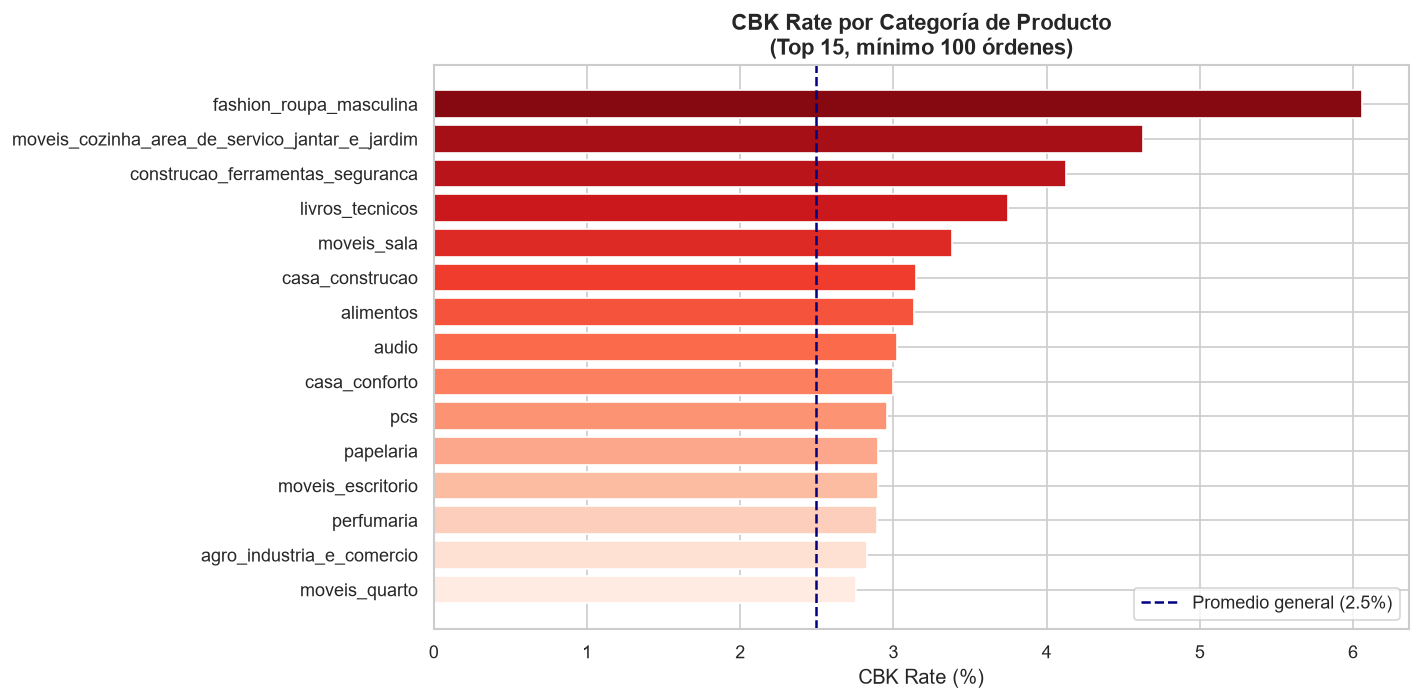

In [6]:
cat_cbk = (
    df.groupby('product_category_name')['cbk']
    .agg(cbk_rate='mean', total='count')
    .reset_index()
)
cat_cbk = cat_cbk[cat_cbk['total'] > 100].copy()
cat_cbk['cbk_rate_pct'] = cat_cbk['cbk_rate'] * 100
cat_cbk = cat_cbk.sort_values('cbk_rate_pct', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(cat_cbk['product_category_name'], cat_cbk['cbk_rate_pct'],
               color=sns.color_palette('Reds_r', len(cat_cbk)))
ax.axvline(cbk_rate, color='navy', linestyle='--', linewidth=1.5, label=f'Promedio general ({cbk_rate:.1f}%)')
ax.set_xlabel('CBK Rate (%)')
ax.set_title('CBK Rate por Categoría de Producto\n(Top 15, mínimo 100 órdenes)', fontsize=13, fontweight='bold')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('img/cbk_rate_categoria.png')
plt.show()

## 5. Gráfico 2 — CBK Rate por Número de Cuotas

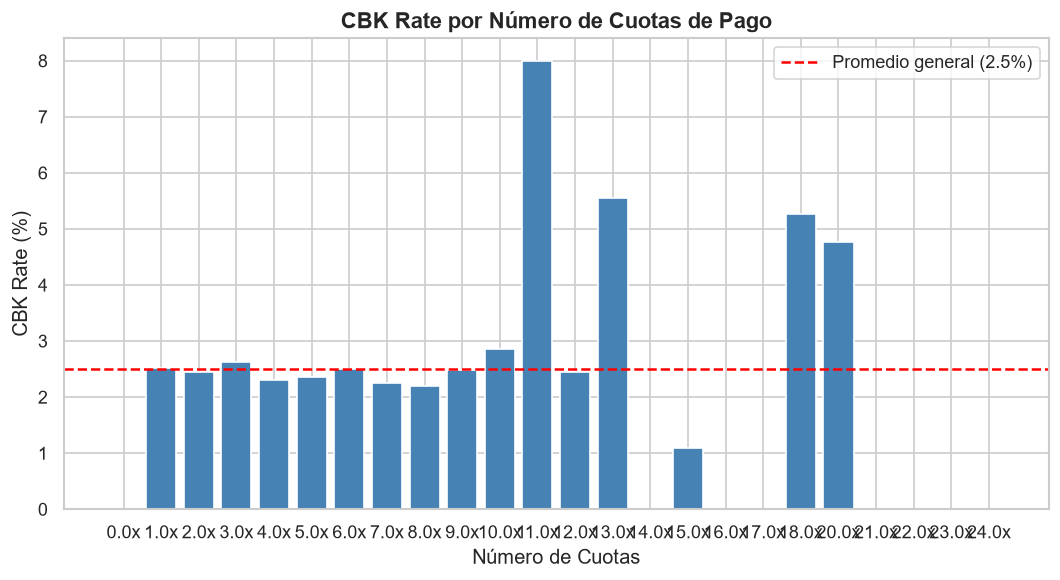

 payment_installments  cbk_rate_pct  total
                  0.0      0.000000      3
                  1.0      2.507982  53868
                  2.0      2.444201  13665
                  3.0      2.619007  11722
                  4.0      2.303625   7944
                  5.0      2.350784   5998
                  6.0      2.498914   4602
                  7.0      2.247807   1824
                  8.0      2.204130   5036
                  9.0      2.479339    726
                 10.0      2.854633   6831
                 11.0      8.000000     25
                 12.0      2.453988    163
                 13.0      5.555556     18
                 14.0      0.000000     16
                 15.0      1.086957     92
                 16.0      0.000000      7
                 17.0      0.000000      7
                 18.0      5.263158     38
                 20.0      4.761905     21
                 21.0      0.000000      5
                 22.0      0.000000      1
           

In [7]:
cuotas_cbk = (
    df.groupby('payment_installments')
    .agg(cbk_rate=('cbk', 'mean'), total=('cbk', 'count'))
    .reset_index()
)
cuotas_cbk['cbk_rate_pct'] = cuotas_cbk['cbk_rate'] * 100

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(cuotas_cbk['payment_installments'].astype(str) + 'x',
       cuotas_cbk['cbk_rate_pct'],
       color='steelblue', edgecolor='white')
ax.axhline(cbk_rate, color='red', linestyle='--', linewidth=1.5, label=f'Promedio general ({cbk_rate:.1f}%)')
ax.set_xlabel('Número de Cuotas')
ax.set_ylabel('CBK Rate (%)')
ax.set_title('CBK Rate por Número de Cuotas de Pago', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('img/cbk_rate_cuotas.png')
plt.show()

print(cuotas_cbk[['payment_installments', 'cbk_rate_pct', 'total']].to_string(index=False))

## 6. Gráfico 3 — Distribución de Precio: CBK vs No-CBK

C:\Users\rober\AppData\Local\Temp\ipykernel_7472\1038138718.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


ValueError: The palette dictionary is missing keys: {'1', '0'}

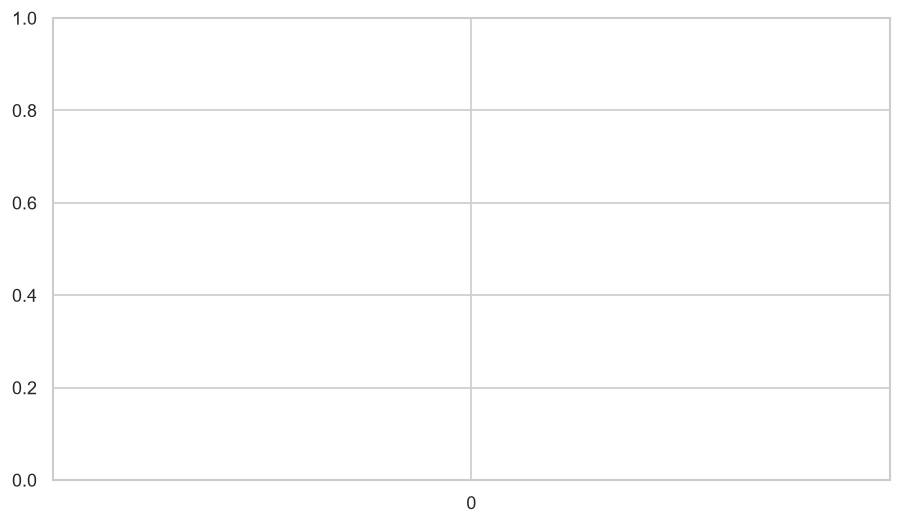

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
    data=df[df['price'] < df['price'].quantile(0.95)],  # excluir outliers extremos
    x='cbk', y='price', ax=ax,
    palette={0: 'cornflowerblue', 1: 'tomato'}
)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Sin CBK', 'Con CBK'])
ax.set_ylabel('Precio ($)')
ax.set_title('Distribución de Precio por Presencia de CBK\n(sin outliers extremos, p95)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('img/precio_cbk_boxplot.png')
plt.show()

## 7. Gráfico 4 — Mapa de Calor de Correlaciones con CBK

In [ ]:
cols_corr = ['cbk', 'price', 'payment_installments', 'freight_value', 'discount', 'profit', 'has_shipping']
corr = df[cols_corr].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, ax=ax, linewidths=0.5)
ax.set_title('Correlación entre Variables y CBK', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('img/correlacion_cbk.png')
plt.show()

## 8. Gráfico 5 — Impacto del CBK en el Profit Total

In [ ]:
profit_sin_cbk = df[df['cbk'] == 0]['profit'].sum()
perdida_cbk_total = perdida_total  # ya calculado arriba
profit_neto = profit_sin_cbk + perdida_cbk_total

labels = ['Profit (sin CBK)', 'Pérdida por CBK', 'Profit Neto Total']
valores = [profit_sin_cbk, perdida_cbk_total, profit_neto]
colores = ['seagreen', 'tomato', 'steelblue']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, valores, color=colores, edgecolor='white')
for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + abs(min(valores))*0.02,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('USD')
ax.set_title('Impacto del CBK en el Profit Total de Olist', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('img/impacto_cbk_profit.png')
plt.show()

## 9. Exportar CSV para SQL y Tableau

In [ ]:
cols_export = [
    'order_id', 'product_category_name', 'payment_installments', 'price',
    'overhead_cost', 'freight_value', 'cbk', 'profit', 'seller_id',
    'discount', 'has_shipping', 'tpv', 'cogs'
]
df[cols_export].to_csv('exports_tableau/export_para_sql.csv', index=False)
print(f'Exportado: exports_tableau/export_para_sql.csv ({len(df):,} filas)')

## 10. Resumen de Hallazgos (para el Deck)

In [ ]:
cat_top = cat_cbk.iloc[0]
cuotas_max = cuotas_cbk.loc[cuotas_cbk['cbk_rate_pct'].idxmax()]

print('=== HALLAZGOS PARA EL EXECUTIVE SUMMARY ===')
print(f'1. CBK rate general:           {cbk_rate:.2f}% ({total_cbk:,} órdenes de {total_ordenes:,})')
print(f'2. Pérdida total por CBK:      ${perdida_total:,.2f}')
print(f'3. Pérdida promedio por CBK:   ${perdida_promedio:,.2f}')
print(f'4. Categoría con más CBK:      {cat_top["product_category_name"]} ({cat_top["cbk_rate_pct"]:.1f}%)')
print(f'5. Cuotas con más CBK:         {int(cuotas_max["payment_installments"])}x ({cuotas_max["cbk_rate_pct"]:.1f}%)')
print(f'6. Impacto reducción CBK 50%:  ahorro de ${abs(perdida_total)*0.5:,.2f}')